In [2]:
# ============================================================
# BUSINESS INTELLIGENCE MINI PROJECT
# Customer Segmentation using K-Means Clustering
# ============================================================

# ============================================================
# STEP 1 : Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Clustering
from sklearn.cluster import KMeans

# Evaluation
from sklearn.metrics import silhouette_score

# ============================================================
# STEP 2 : Load Dataset
# ============================================================

df = pd.read_csv("C:\\Users\\LENOVO\\Downloads\\Cleaned_Customer_Data.csv")

df.head()

# ============================================================
# STEP 3 : Dataset Overview
# ============================================================

print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print()

print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

print()

print("="*60)
print("SUMMARY STATISTICS")
print("="*60)

df.describe().T


# ============================================================
# STEP 4 : Clustering Problem
# ============================================================

print("""
Business Problem

The telecom company wants to identify different customer
segments based on customer demographics,
subscription behaviour,
service usage and revenue.

Machine Learning Task

Unsupervised Learning

Algorithm

K-Means Clustering

Objective

Identify customers having similar characteristics
so that the company can design targeted marketing
and customer retention strategies.
""")

DATASET SHAPE
(7043, 36)

DATASET INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                

Missing Values
Customer ID                          0
Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited 

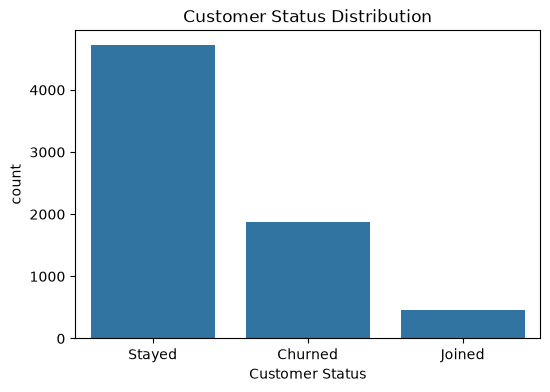

(7043, 34)
Categorical Columns: 19
Numerical Columns: 15
Encoded Data Shape: (7043, 1173)


In [3]:
# ============================================================
# STEP 5 : Exploratory Data Analysis
# ============================================================

print("Missing Values")

print(df.isnull().sum())

print()

print("Duplicate Records :", df.duplicated().sum())

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Customer Status"
)

plt.title("Customer Status Distribution")

plt.show()

# ============================================================
# STEP 6 : Prepare Data
# ============================================================

cluster_df = df.drop(
    columns=[
        "Customer ID",
        "Customer Status"
    ]
)

print(cluster_df.shape)
# ============================================================
# STEP 7 : Encode Categorical Variables
# ============================================================

# Identify categorical and numerical columns
categorical_columns = cluster_df.select_dtypes(include="object").columns
numerical_columns = cluster_df.select_dtypes(exclude="object").columns

print("Categorical Columns:", len(categorical_columns))
print("Numerical Columns:", len(numerical_columns))

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_columns
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numerical_columns
        )
    ]
)

# Transform the dataset
cluster_encoded = preprocessor.fit_transform(cluster_df)

print("Encoded Data Shape:", cluster_encoded.shape)

SELECTED FEATURES
   Age  Tenure in Months  Monthly Charge  Total Charges  Total Revenue  \
0   37                 9            65.6         593.30         974.81   
1   46                 9            -4.0         542.40         610.28   
2   50                 4            73.9         280.85         415.45   
3   78                13            98.0        1237.85        1599.51   
4   75                 3            83.9         267.40         289.54   

   Number of Referrals  Avg Monthly GB Download  
0                    2                     16.0  
1                    0                     10.0  
2                    0                     30.0  
3                    1                      4.0  
4                    3                     11.0  

Dataset Shape: (7043, 7)
Scaling Completed Successfully!


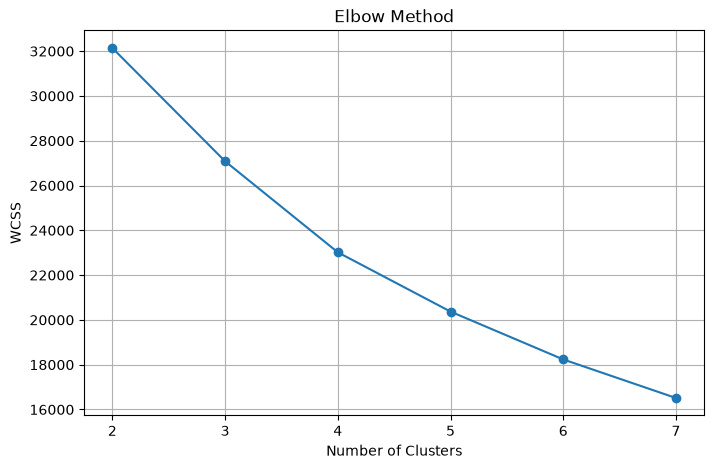

In [4]:
# ============================================================
# STEP 8 : Feature Selection for Clustering
# ============================================================

# Select business-relevant numerical features
cluster_df = df[[
    "Age",
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    "Total Revenue",
    "Number of Referrals",
    "Avg Monthly GB Download"
]]

print("="*60)
print("SELECTED FEATURES")
print("="*60)

print(cluster_df.head())

print("\nDataset Shape:", cluster_df.shape)
# ============================================================
# STEP 9 : Feature Scaling
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

print("Scaling Completed Successfully!")
# ============================================================
# STEP 10 : Elbow Method
# ============================================================

from sklearn.cluster import KMeans

wcss = []

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(cluster_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,8),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

   Number of Clusters  Silhouette Score
0                   2          0.338278
1                   3          0.250860
2                   4          0.262991
3                   5          0.265737
4                   6          0.265689
5                   7          0.254673


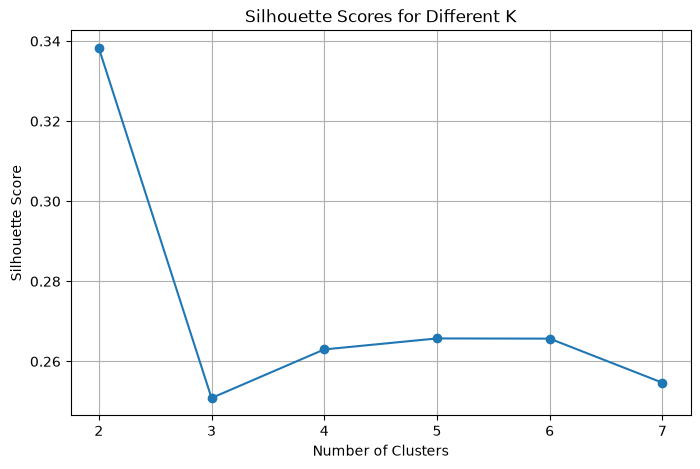

In [6]:
# ============================================================
# STEP 11 : Silhouette Score for Different K
# ============================================================

from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 8):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(cluster_scaled)

    score = silhouette_score(cluster_scaled, labels)

    scores.append(score)

results = pd.DataFrame({
    "Number of Clusters": range(2, 8),
    "Silhouette Score": scores
})

print(results)

plt.figure(figsize=(8,5))
plt.plot(results["Number of Clusters"],
         results["Silhouette Score"],
         marker='o')

plt.title("Silhouette Scores for Different K")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

Cluster Distribution
Cluster
1    4800
0    2243
Name: count, dtype: int64
           Age  Tenure in Months  Monthly Charge  Total Charges  \
Cluster                                                           
0        47.30             57.73           89.09        5188.67   
1        46.14             20.54           51.68         921.36   

         Total Revenue  Number of Referrals  Avg Monthly GB Download  
Cluster                                                               
0              6621.03                 3.03                    27.97  
1              1358.37                 1.45                    17.03  
Customer Status  Churned  Joined  Stayed
Cluster                                 
0                    345       0    1898
1                   1524     454    2822


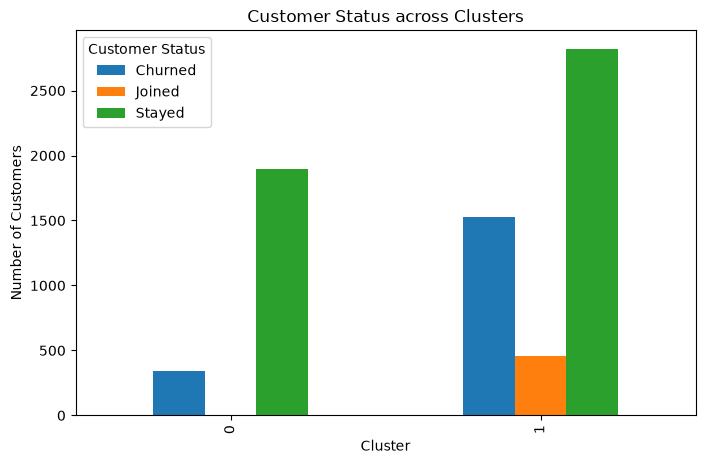

In [7]:
# ============================================================
# STEP 12 : Final K-Means Model
# ============================================================

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(cluster_scaled)

cluster_df["Cluster"] = clusters

print("="*50)
print("Cluster Distribution")
print("="*50)

print(cluster_df["Cluster"].value_counts())
# ============================================================
# STEP 13 : Cluster Profiling
# ============================================================

profile_df = df.copy()

profile_df["Cluster"] = clusters

cluster_profile = profile_df.groupby("Cluster")[[
    "Age",
    "Tenure in Months",
    "Monthly Charge",
    "Total Charges",
    "Total Revenue",
    "Number of Referrals",
    "Avg Monthly GB Download"
]].mean().round(2)

print(cluster_profile)
# ============================================================
# STEP 14 : Customer Status by Cluster
# ============================================================

status_cluster = pd.crosstab(
    profile_df["Cluster"],
    profile_df["Customer Status"]
)

print(status_cluster)

status_cluster.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Status across Clusters")

plt.ylabel("Number of Customers")

plt.show()

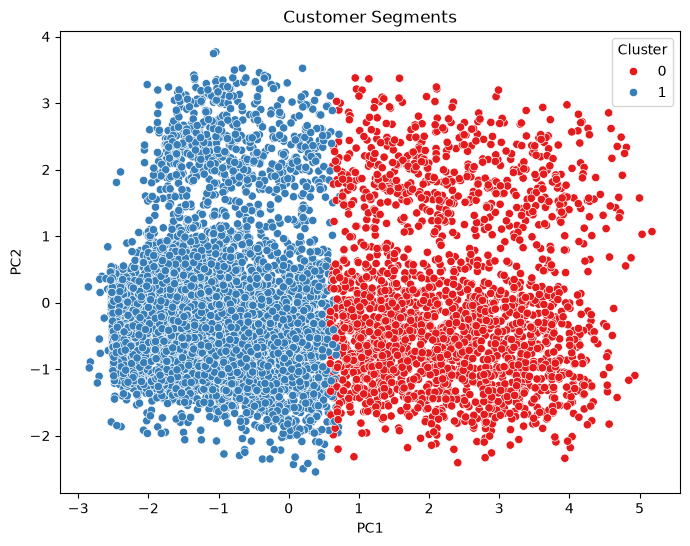

In [8]:
# ============================================================
# STEP 15 : PCA Visualization
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(cluster_scaled)

plot_df = pd.DataFrame({
    "PC1": cluster_pca[:,0],
    "PC2": cluster_pca[:,1],
    "Cluster": clusters
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segments")

plt.show()
